# MVP Conceitual — Ciência de Dados & IA Aplicada
## Desafio 1- Inferência de Fluxos Origem-Destino (O-D) com IA

## Visão Geral do Projeto

Este projeto propõe a construção de um MVP analítico para inferência de fluxos Origem-Destino (O-D) utilizando registros urbanos capturados por sensores de monitoramento viário.

A solução utiliza técnicas de processamento de dados, análise temporal e regras de coerência espacial para reconstruir trajetos inferidos entre sensores urbanos, permitindo identificar padrões de mobilidade, corredores de fluxo e comportamentos recorrentes do tráfego urbano.

Como a base analisada não possui rastreamento contínuo explícito das trajetórias, o modelo adota uma abordagem inferencial baseada em:

- sequência temporal dos registros;
- proximidade lógica entre sensores;
- tempo estimado entre deslocamentos;
- recorrência dos padrões observados.

Durante o desenvolvimento do MVP foram aplicadas etapas de:

- tratamento e seleção amostral dos dados;
- organização temporal dos registros;
- reconstrução de fluxos;
- geração de matriz Origem-Destino;
- análise exploratória visual;
- identificação de padrões em horários de pico.

Os resultados obtidos demonstram o potencial da integração entre análise de dados, mobilidade urbana e inteligência analítica como base inicial para futuras aplicações em cidades inteligentes, sistemas IoT e gêmeos digitais urbanos.

### 1. Integração do Google Drive ao Google Colab

In [1]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


### 2. Importação das Bibliotecas

In [5]:
import pandas as pd
import matplotlib.pyplot as plt


### 3. Seleção e Carregamento dos Dados Relevantes do Dataset

In [6]:
colunas = [
    'NSerie',
    'Endereco',
    'Sentido',
    'Datatrafego',
    'Latitude',
    'Longitude',
    'Placa',
    'Velocidade 1'
]

df = pd.read_csv(
    '/content/drive/MyDrive/amostra_fluxo.csv',
    usecols=colunas
)

### 4. Exploração Inicial da Base

In [7]:
df.head()

,NSerie,Endereco,Sentido,Datatrafego,Latitude,Longitude,Placa,Velocidade 1
0,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,01/01/2026 00:03:32,-23.52899,-47.48995,DA2BB62F2D5374000D0185FA0A4D52D820D92C54CEFD3A...,48.0
1,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,01/01/2026 00:10:29,-23.52899,-47.48995,044098ABE450B540252BCA2F04EAAA2A9716989FCE51DA...,40.0
2,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,01/01/2026 00:11:01,-23.52899,-47.48995,879729CF6D14FC8502EB295702A4C806822F4DC5241D58...,47.0
3,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,01/01/2026 00:12:39,-23.52899,-47.48995,2B5829669BA2210CAF4171D5E191BC7BB841C401624927...,48.0
4,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,01/01/2026 00:13:33,-23.52899,-47.48995,26ED035298D41F201508929ACEC4FF913CF755433FE709...,45.0


In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 8 columns):
 #   Column        Non-Null Count  Dtype  
---  ------        --------------  -----  
 0   NSerie        50000 non-null  int64  
 1   Endereco      50000 non-null  object 
 2   Sentido       50000 non-null  object 
 3   Datatrafego   50000 non-null  object 
 4   Latitude      50000 non-null  float64
 5   Longitude     50000 non-null  float64
 6   Placa         50000 non-null  object 
 7   Velocidade 1  50000 non-null  float64
dtypes: float64(3), int64(1), object(4)
memory usage: 3.1+ MB


### 5. Conversão Temporal dos Registros

In [9]:
df['Datatrafego'] = pd.to_datetime(
    df['Datatrafego'],
    dayfirst=True
)

### 6. Construção da Amostra Analítica e Ordenação Temporal

In [10]:
df['Placa'].nunique()

37966

In [11]:
placas_amostra = df['Placa'].drop_duplicates().sample(1000, random_state=42)

In [12]:
df_amostra = df[df['Placa'].isin(placas_amostra)]

In [13]:
df_amostra = df_amostra.sort_values(
    ['Placa', 'Datatrafego']
)

In [14]:
df_amostra.head(20)

,NSerie,Endereco,Sentido,Datatrafego,Latitude,Longitude,Placa,Velocidade 1
17829,1020,"Rua Diva Mugnaini Ravacci, n?15",Centro/Bairro,2026-01-02 06:50:31,-23.504380,-47.506750,006B6B4A1DB0B43FF21D3393A690EC938E58CF7CFFFA7C...,45.0
30345,1802,Rua Souza Pereira X Rua Dr. Alvaro Soares,Centro/Bairro,2026-01-01 20:06:41,-23.497410,-47.454895,00902F1746BCA73885021DC45C64A3C8D66B9F3CF98A8D...,13.0
10468,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-01 23:21:27,-23.528990,-47.489950,00C0C1E0256602A086ADE055B58C4AA4FABC13F39F728C...,41.0
27857,1855,Av. Antonio Carlos Comitre X Rua Frederico Julio,Bairro/Centro,2026-01-01 14:41:34,-23.524404,-47.464892,0105CF1852646FF40B2D3CB9A8190D0A960AE89E8DB07A...,45.0
43279,1022,"Av. Dr. Armando Pannunzio, n?1893",Bairro/Centro,2026-01-01 17:50:22,-23.529730,-47.489580,013C7641D3F630161A561AB7E8C9CA0847FE0EA2FCD407...,39.0
35597,1802,Rua Souza Pereira X Rua Dr. Alvaro Soares,Centro/Bairro,2026-01-02 05:24:24,-23.497410,-47.454895,013C7641D3F630161A561AB7E8C9CA0847FE0EA2FCD407...,33.0
20971,1802,Rua Souza Pereira X Rua Dr. Alvaro Soares,Centro/Bairro,2026-01-01 09:28:35,-23.497410,-47.454895,01EA95D195050F480C044897F05149F48AAED17CA0E5B8...,11.0
16258,1020,"Rua Diva Mugnaini Ravacci, n?15",Centro/Bairro,2026-01-01 22:08:24,-23.504380,-47.506750,01EA95D195050F480C044897F05149F48AAED17CA0E5B8...,39.0
20667,1020,"Rua Diva Mugnaini Ravacci, n?15",Centro/Bairro,2026-01-02 13:32:42,-23.504380,-47.506750,01EA95D195050F480C044897F05149F48AAED17CA0E5B8...,45.0
37390,1021,"Av. Dr. Armando Pannunzio, n?1800",Centro/Bairro,2026-01-03 08:17:10,-23.528990,-47.489950,01FBDA262352009B174C165803824F3CFFD5B8F437FB9F...,56.0


### 7. Inferência Temporal dos Fluxos Origem-Destino (O-D)

In [15]:
df_amostra['Sensor_Destino'] = (
    df_amostra.groupby('Placa')['NSerie']
    .shift(-1)
)

In [16]:
df_amostra['Horario_Destino'] = (
    df_amostra.groupby('Placa')['Datatrafego']
    .shift(-1)
)

In [17]:
df_amostra['Tempo_Diferenca'] = (
    df_amostra['Horario_Destino']
    - df_amostra['Datatrafego']
)

In [18]:
df_amostra['Tempo_Minutos'] = (
    df_amostra['Tempo_Diferenca']
    .dt.total_seconds() / 60
)

In [19]:
df_fluxo = df_amostra[
    (df_amostra['Tempo_Minutos'] >= 1) &
    (df_amostra['Tempo_Minutos'] <= 120)
]

In [20]:
matriz_od = (
    df_fluxo.groupby(
        ['NSerie', 'Sensor_Destino']
    )
    .size()
    .reset_index(name='Fluxo')
)

### 8. Visualização Inicial da Matriz Origem-Destino

In [21]:
matriz_od.head(20)

,NSerie,Sensor_Destino,Fluxo
0,966,966.0,3
1,966,1021.0,4
2,966,1022.0,1
3,999,999.0,6
4,1017,966.0,1
5,1017,1017.0,5
6,1017,1020.0,1
7,1017,1021.0,2
8,1017,1755.0,1
9,1017,1802.0,1


### 9. Validação Exploratória dos Fluxos Inferidos

In [22]:
df_fluxo[
    [
        'Placa',
        'NSerie',
        'Sensor_Destino',
        'Datatrafego',
        'Horario_Destino',
        'Tempo_Minutos'
    ]
].head(20)

,Placa,NSerie,Sensor_Destino,Datatrafego,Horario_Destino,Tempo_Minutos
26586,052957F5EF8F6E723C30576085FBF9A25D71B812015A00...,1802,1802.0,2026-01-01 17:19:53,2026-01-01 17:23:54,4.016667
26652,052957F5EF8F6E723C30576085FBF9A25D71B812015A00...,1802,1802.0,2026-01-01 17:23:54,2026-01-01 17:33:44,9.833333
18178,09B9190B736EF14AB0AFDAC1D1141C72237088F7634CF9...,1020,1020.0,2026-01-02 08:45:59,2026-01-02 10:36:35,110.600000
39423,09B9190B736EF14AB0AFDAC1D1141C72237088F7634CF9...,1020,1020.0,2026-01-03 09:13:50,2026-01-03 09:29:20,15.500000
42648,09B9190B736EF14AB0AFDAC1D1141C72237088F7634CF9...,1020,1020.0,2026-01-03 11:36:55,2026-01-03 12:13:32,36.616667
15789,0DAD4A8EE5FFDF41EE369D50B1A80D1CFE5087554B90DF...,999,999.0,2026-01-02 16:13:31,2026-01-02 17:05:52,52.350000
16150,0DAD4A8EE5FFDF41EE369D50B1A80D1CFE5087554B90DF...,999,999.0,2026-01-02 17:05:52,2026-01-02 18:21:43,75.850000
42397,0E56B8E5D1DF93919A87E424767249856E175808277478...,1017,1017.0,2026-01-02 13:41:44,2026-01-02 13:50:45,9.016667
10604,12DE942F19D3A9F5019773514917D95AD5574AFF8BE4C3...,1017,1755.0,2026-01-01 10:48:40,2026-01-01 11:26:15,37.583333
16265,13F2FD36BEE7F9731D3D95907CC727AE0709A39E41B62C...,1020,1802.0,2026-01-01 22:10:51,2026-01-01 22:49:29,38.633333


### 10. Identificação dos Fluxos Urbanos Mais Recorrentes

In [23]:
matriz_od.sort_values(
    'Fluxo',
    ascending=False
).head(15)

,NSerie,Sensor_Destino,Fluxo
10,1020,1020.0,9
3,999,999.0,6
18,1022,1020.0,6
30,1802,1802.0,6
14,1021,1021.0,6
5,1017,1017.0,5
1,966,1021.0,4
15,1021,1022.0,4
0,966,966.0,3
19,1022,1021.0,3


### 11. Seleção dos Fluxos Mais Relevantes

In [24]:
top_fluxos = matriz_od.sort_values(
    'Fluxo',
    ascending=False
).head(10)

### 12. Visualização Gráfica dos Principais Fluxos Origem-Destino

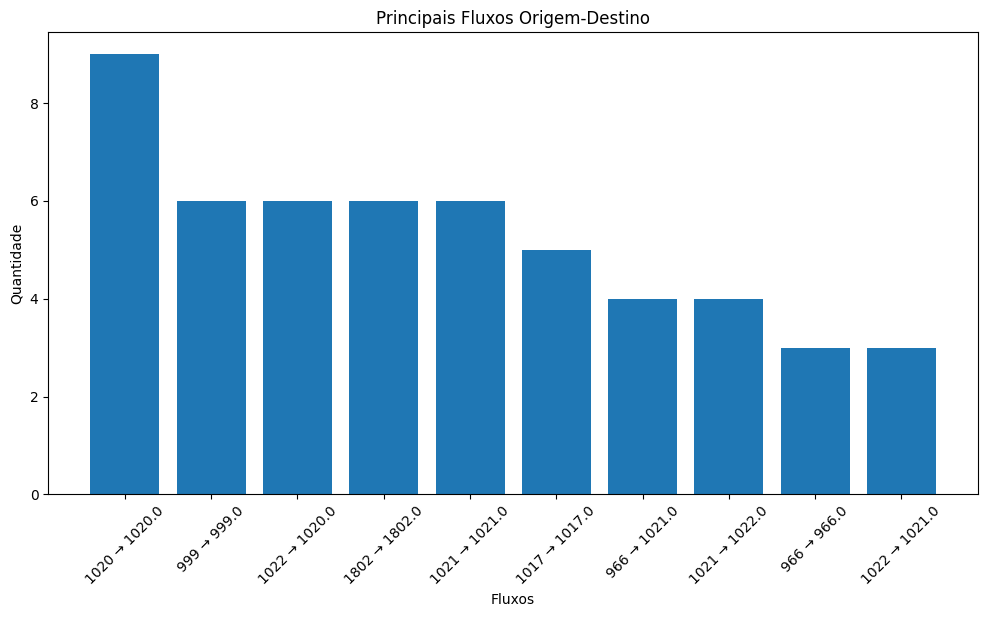

In [28]:
plt.figure(figsize=(12,6))

plt.bar(
    top_fluxos['NSerie'].astype(str) + ' → ' +
    top_fluxos['Sensor_Destino'].astype(str),
    top_fluxos['Fluxo']
)

plt.xticks(rotation=45)

plt.title('Principais Fluxos Origem-Destino')

plt.xlabel('Fluxos')

plt.ylabel('Quantidade')

plt.show()

## Interpretação Analítica do Gráfico das Principais Fluxos Origem-Destino

Nesta etapa foi gerado um gráfico de barras representando os principais fluxos inferidos entre sensores urbanos.

Cada barra representa:

um sensor de origem;
um sensor de destino;
a frequência observada do deslocamento inferido.

A visualização permite identificar rapidamente:

conexões urbanas mais recorrentes;
possíveis corredores viários relevantes;
padrões iniciais de mobilidade detectados pela inferência temporal.

A rotação dos rótulos (rotation=45) foi aplicada para melhorar a legibilidade dos fluxos exibidos no eixo horizontal.

### 13. Preparação da Estrutura Visual da Matriz Origem-Destino

In [29]:
placa_exemplo = df_fluxo['Placa'].iloc[0]

In [30]:
matriz_visual = matriz_od.pivot_table(
    index='NSerie',
    columns='Sensor_Destino',
    values='Fluxo',
    fill_value=0
)

In [31]:
matriz_visual

Sensor_Destino,966.0,999.0,1017.0,1020.0,1021.0,1022.0,1755.0,1802.0,1853.0,1855.0
NSerie,,,,,,,,,,
966,3.0,0.0,0.0,0.0,4.0,1.0,0.0,0.0,0.0,0.0
999,0.0,6.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
1017,1.0,0.0,5.0,1.0,2.0,0.0,1.0,1.0,0.0,0.0
1020,0.0,0.0,0.0,9.0,3.0,0.0,0.0,2.0,0.0,0.0
1021,0.0,0.0,0.0,3.0,6.0,4.0,0.0,0.0,0.0,0.0
1022,1.0,0.0,1.0,6.0,3.0,1.0,1.0,1.0,0.0,0.0
1755,1.0,0.0,0.0,1.0,1.0,0.0,1.0,0.0,0.0,2.0
1802,0.0,0.0,0.0,0.0,1.0,0.0,2.0,6.0,0.0,0.0
1853,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0


### 14. Inspeção Exploratória de Trajetória Individual

In [32]:
df_fluxo[
    df_fluxo['Placa'] == placa_exemplo
][
    [
        'NSerie',
        'Sensor_Destino',
        'Datatrafego',
        'Horario_Destino',
        'Tempo_Minutos'
    ]
]

,NSerie,Sensor_Destino,Datatrafego,Horario_Destino,Tempo_Minutos
26586,1802,1802.0,2026-01-01 17:19:53,2026-01-01 17:23:54,4.016667
26652,1802,1802.0,2026-01-01 17:23:54,2026-01-01 17:33:44,9.833333


### 15. Construção Visual da Matriz Origem-Destino (O-D)

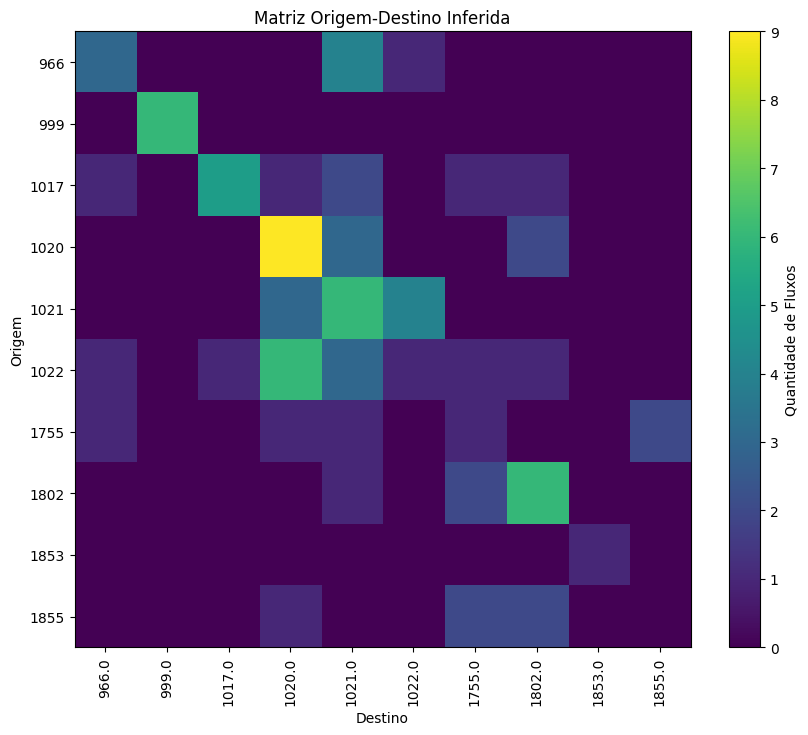

In [33]:
plt.figure(figsize=(10,8))

plt.imshow(matriz_visual)

plt.colorbar(label='Quantidade de Fluxos')

plt.xticks(
    range(len(matriz_visual.columns)),
    matriz_visual.columns,
    rotation=90
)

plt.yticks(
    range(len(matriz_visual.index)),
    matriz_visual.index
)

plt.xlabel('Destino')

plt.ylabel('Origem')

plt.title('Matriz Origem-Destino Inferida')

plt.show()

## Interpretação Analítica da Matriz O-D

A matriz origem-destino representa a intensidade dos deslocamentos inferidos entre sensores urbanos a partir da sequência temporal das leituras veiculares.

Cada célula da matriz indica:

- um ponto de origem;
- um ponto de destino;
- a frequência observada do fluxo entre esses sensores.

Quanto maior a intensidade da cor, maior a recorrência do deslocamento inferido naquele trecho urbano.

A concentração visual dos fluxos permite identificar:

- possíveis corredores viários predominantes;
- padrões recorrentes de mobilidade;
- regiões com maior intensidade de circulação;
- potenciais áreas de interesse para planejamento urbano orientado por dados.

Mesmo sem rastreamento contínuo dos veículos, a abordagem demonstra que é possível inferir padrões urbanos relevantes utilizando regras temporais e análise exploratória de dados provenientes da infraestrutura sensorial existente.

In [34]:
df_amostra['Hora'] = df_amostra['Datatrafego'].dt.hour

In [39]:
rush_manha = df_amostra[
    (df_amostra['Hora'] >= 7) &
    (df_amostra['Hora'] <= 9)
]

In [40]:
vias_fluxo1 = (
    rush_manha.groupby('Endereco')
    .size()
    .reset_index(name='Fluxo')
    .sort_values('Fluxo', ascending=False)
    .head(10)
)

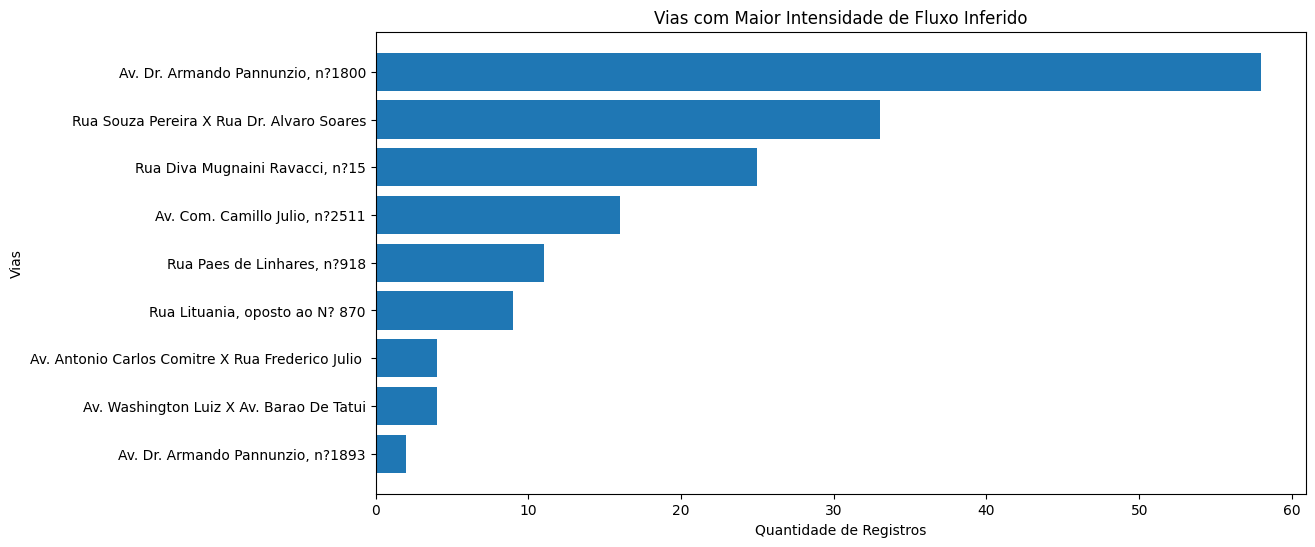

In [41]:
plt.figure(figsize=(12,6))

plt.barh(
    vias_fluxo1['Endereco'],
    vias_fluxo1['Fluxo'],
)

plt.xlabel('Quantidade de Registros')

plt.ylabel('Vias')

plt.title('Vias com Maior Intensidade de Fluxo Inferido')

plt.gca().invert_yaxis()

plt.show()

In [42]:
rush_tarde_noite = df_amostra[
    (df_amostra['Hora'] >= 17) &
    (df_amostra['Hora'] <= 19)
]

In [43]:
vias_fluxo2 = (
    rush_tarde_noite.groupby('Endereco')
    .size()
    .reset_index(name='Fluxo')
    .sort_values('Fluxo', ascending=False)
    .head(10)
)

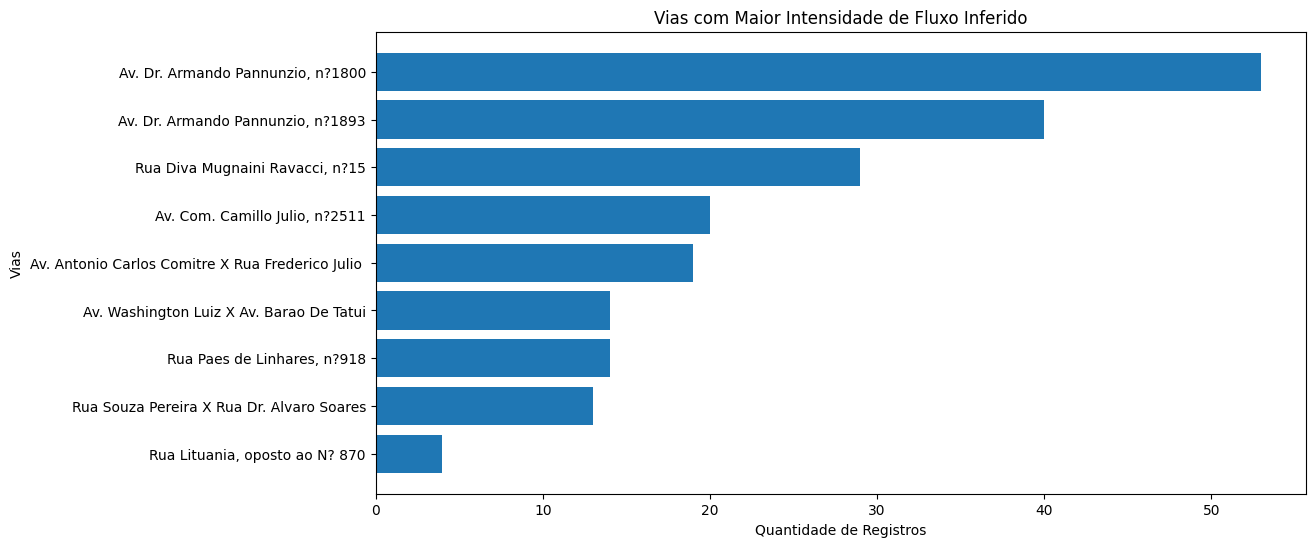

In [44]:
plt.figure(figsize=(12,6))

plt.barh(
    vias_fluxo2['Endereco'],
    vias_fluxo2['Fluxo'],
)

plt.xlabel('Quantidade de Registros')

plt.ylabel('Vias')

plt.title('Vias com Maior Intensidade de Fluxo Inferido')

plt.gca().invert_yaxis()

plt.show()

## Interpretação Analítica do Período de Rush (Manhã e Tarde_Noite)

### Análise Comparativa — Fluxos em Horários de Pico

A análise comparativa entre os períodos de pico da manhã e pico da tarde/noite evidencia alterações relevantes nos padrões de mobilidade urbana observados pela malha de sensores.

Os resultados demonstram que determinadas vias apresentam maior concentração de deslocamentos em horários específicos, indicando comportamentos distintos relacionados a deslocamentos de trabalho, estudo, retorno residencial e distribuição espacial do tráfego ao longo do dia.

Além da variação no volume de registros, observa-se também mudança na hierarquia das vias mais movimentadas, sugerindo que diferentes regiões da cidade assumem maior relevância operacional dependendo do período analisado.

Esse comportamento reforça a importância de análises temporais na construção de modelos de mobilidade urbana, permitindo identificar corredores críticos, padrões recorrentes e possíveis oportunidades de otimização viária e planejamento inteligente da cidade.